# Projektarbeit / Aufgabe 4: Analyse der Taschengeldverteilung
## DHBW Ravensburg · Grundlagen Data Science

| Bearbeiter         | Kurs  |
|--------------------|-------|
| Julian Stengele    | TIK24 |
| Johann Flögel      | TIK24 |
| Atussa Mehrawari   | TIK24 |

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

df = pd.read_csv('docs/DatSci_PKA_4.csv', header=None, names=['Taschengeld'])
# Erste 10 Zeilen anzeigen und Anzahl der Datensätze
print(df.head(10))
print(f"\nAnzahl der Datensätze: {len(df)}")


   Taschengeld
0       491.99
1       448.63
2       508.39
3       509.30
4       379.26
5       362.56
6       482.86
7       500.42
8       529.59
9       523.97

Anzahl der Datensätze: 10000


## Aufgabe 1: Deskriptive Statistiken
Berechnung von Mittelwert, Standardabweichung, Skewness und Kurtosis der Taschengeldverteilung

In [ ]:
taschengeld = df.iloc[:, 0]

print("=== AUFGABE 1: DESKRIPTIVE STATISTIKEN ===\n")

# Berechnung der deskriptiven Statistiken
mittelwert = taschengeld.mean()
standardabweichung = taschengeld.std(ddof=1)
skewness = stats.skew(taschengeld.dropna())
kurtosis = stats.kurtosis(taschengeld.dropna(), fisher=True)

print(f"Mittelwert:             {mittelwert:.2f}")
print(f"Standardabweichung:     {standardabweichung:.2f}")
print(f"Skewness:               {skewness:.4f}")
print(f"Kurtosis:               {kurtosis:.4f}")

=== AUFGABE 1: DESKRIPTIVE STATISTIKEN ===

Mittelwert:             492.97
Standardabweichung:     33.64
Skewness:               -1.7100
Kurtosis:               4.8909


## Aufgabe 2: Symmetrie und Schiefe der Verteilung
Überprüfung, ob die Verteilung symmetrisch oder schief ist und ggf. links- oder rechtsschief

=== AUFGABE 2: SYMMETRIE UND SCHIEFE ===

Skewness-Wert: -1.7100
Mittelwert:    492.97
Median:        500.72

Ergebnis: Die Verteilung ist LINKSSCHIEF.
  → Der linke Schwanz ist länger.
  → Mittelwert (492.97) < Median (500.72)


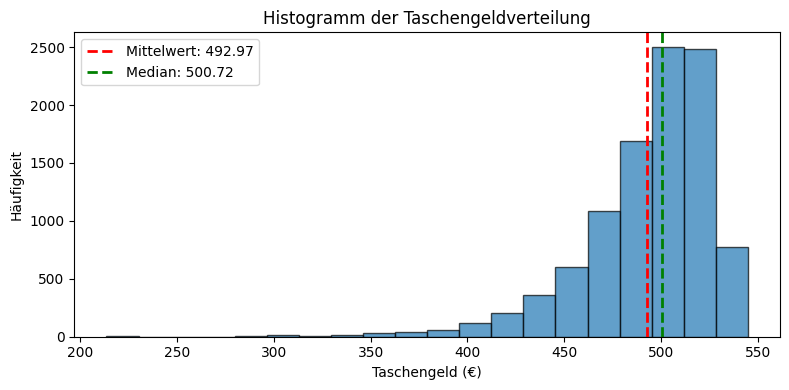

In [ ]:
print("=== AUFGABE 2: SYMMETRIE UND SCHIEFE ===\n")

# Median-Berechnung
median = taschengeld.median()

print(f"Skewness-Wert: {skewness:.4f}")
print(f"Mittelwert:    {mittelwert:.2f}")
print(f"Median:        {median:.2f}\n")

# Logik zur Bestimmung der Verteilung
if abs(skewness) < 0.5:
    print("Ergebnis: Die Verteilung ist annähernd SYMMETRISCH.")
elif skewness > 0.5:
    print("Ergebnis: Die Verteilung ist RECHTSSCHIEF.")
    print("  → Der rechte Schwanz ist länger.")
    print(f"  → Mittelwert ({mittelwert:.2f}) > Median ({median:.2f})")
else:
    print("Ergebnis: Die Verteilung ist LINKSSCHIEF.")
    print("  → Der linke Schwanz ist länger.")
    print(f"  → Mittelwert ({mittelwert:.2f}) < Median ({median:.2f})")

# Visualisierung mit Histogramm und vertikalen Linien für Mittelwert und Median
plt.figure(figsize=(8, 4))
plt.hist(taschengeld, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(mittelwert, color='red', linestyle='--', linewidth=2, label=f'Mittelwert: {mittelwert:.2f}')
plt.axvline(median, color='green', linestyle='--', linewidth=2, label=f'Median: {median:.2f}')
plt.xlabel('Taschengeld (€)')
plt.ylabel('Häufigkeit')
plt.title('Histogramm der Taschengeldverteilung')
plt.legend()
plt.tight_layout()
plt.show()


## Aufgabe 3: Mögliche Gründe für die beobachtete Verteilung
Analyse von potentiellen Ursachen der Taschengeldverteilung

Mögliche Ursachen für die beobachtete Taschengeldverteilung:

1. **Unterschiedliche finanzielle Situationen der Familien**  
   Eltern mit unterschiedlichen Einkommen geben unterschiedliche Beträge

2. **Altersabhängige Unterschiede in der Oberstufe**  
   Jüngere und ältere Schüler erhalten unterschiedliche Beträge

3. **Unterschiedliche Bedürfnisse und Ausgabenverhalten**  
   Unterschiedliche Hobbys, Aktivitäten und Interessen